In [1]:
pip install atproto numpy pandas matplotlib networkx scipy nltk tabulate emoji scikit-learn transformers torch

  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 65.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 56.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 21.1 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 64.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 668.2/668.2 kB 55.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 66.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 65.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 532.3/532.3 MB 46.2 MB/s  0:00:11m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 MB 65.1 MB/s  0:00:05m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 63.3 MB/s  0:00:02m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.0/206.0 MB 63.6 MB/s  0:00:03m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# Social Media and Network Analytics - Assignment 2
## Our Question:
- What are peoples limits to Ai generated content in video games?
## Team Members:
- Mitchell Long: S4007880
- Jimmy Vu: S4006701
- Khang Nguyen: S4005711

In [16]:
from atproto import Client
from account import getAccount
import emoji
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.sentiment import SentimentIntensityAnalyzer
import json
import re
import pandas as pd
from collections import Counter
import tabulate
import matplotlib.pyplot as plt
from transformers import pipeline

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('vader_lexicon')

[nltk_data] Downloading package punkt to /home/tmd12/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/tmd12/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /home/tmd12/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/tmd12/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/tmd12/nltk_data...


True

In [3]:
datasetPath = "./dataset/"
searchQueries = ["Artificial Intelligence, AI, games", "Artificial Intelligence, AI, Iarian", "Artificial Intelligence, AI, Expedition 33", "Artificial Intelligence, AI, Battlefield 6"]
getData = True

### Data Collection and Formatting

In [ ]:
# Running this block will prompt user input for username and password
# Keeping this separate allows us to use client apis later in the notebook 
# without needing to recollect data again
username, password = getAccount()
client = Client()
client.login(username, password)

In [ ]:
# Run a search query and collect posts
if (getData):
        
    structured_posts = []
    for q in searchQueries:
        search_results = client.app.bsky.feed.search_posts({"q": q, "limit": 100})
        display(search_results)

        # Iterate through each collected post and its replies
        for post in search_results.posts:

            # Print posts for output proof
            name = post.author.display_name

            if name is None:
                name = post.author.handle
                
            print(name + ": ")
            print(post.record.text)
            print('\n')

            # Fetch thread for this post using the uri
            thread = client.app.bsky.feed.get_post_thread({
                "uri": post.uri
            })

            replies_data = []

            replies = getattr(thread.thread, "replies", [])

            # Create JSON structure for each reply
            for reply in replies:
                if hasattr(reply, "post"):

                    reply_post = reply.post

                    replies_data.append({
                        "reply_id": reply_post.uri,
                        "text": reply_post.record.text,
                        "created_at": getattr(reply_post.record, "created_at", None),

                        "author": {
                            "display_name": reply_post.author.display_name,
                            "handle": reply_post.author.handle
                        },

                        "engagement": {
                            "likes": reply_post.like_count,
                            "replies": reply_post.reply_count,
                            "reposts": reply_post.repost_count
                        }
                    })

            # Create JSON structure for original post and append comments
            structured_post = {
                "post_id": post.uri,
                "text": post.record.text,
                "created_at": getattr(post.record, "created_at", None),

                "author": {
                    "display_name": post.author.display_name,
                    "handle": post.author.handle,
                    "did": post.author.did
                },

                "engagement": {
                    "likes": post.like_count,
                    "reposts": post.repost_count,
                    "replies": post.reply_count,
                    "quotes": post.quote_count
                },

                "metadata": {
                    "lang": getattr(post.record, "langs", [])
                },

                # Comments appended here
                "comments": replies_data
            }

            # Add posts to one object
            structured_posts.append(structured_post)

        # Create and save data to JSON file
        data = {'posts': structured_posts}

    with open(datasetPath + "bluesky_posts.json", "w", encoding="utf-8") as file:
        json.dump(data, file, indent=4, ensure_ascii=False)

# Part 1 Analysis - Network Connections
Resort the json by likes so we can collect network of the most influential posts

In [ ]:
with open(datasetPath + "bluesky_posts.json", "r") as file:
    data = json.load(file)

data["posts"].sort(
    key=lambda post: post["engagement"]["likes"],
    reverse=True
)

with open(datasetPath + "sorted_bluesky_posts.json", "w", encoding="utf-8") as file:
    json.dump(data, file, indent=4, ensure_ascii=False)

Time to collect followers and following from the top most liked posts

In [ ]:
# HEADS UP THIS PART TAKES A LONG TIME AS IT IS RUNNING MANY API CALLS TO COLLECT COUNTS
# Run the sorting cell before running this cell
with open(datasetPath + "sorted_bluesky_posts.json", "r") as file:
    data = json.load(file)

posts = data["posts"]

# Here sets how many posts (Currently at top 50 posts)
top_posts = posts[:50]

results = []

for post in top_posts:
    # We will use the did to differenciate from accounts as it is unique
    did = post["author"]["did"]

    handle = post["author"]["handle"]

    print(f"Fetching: {handle}")

    # We collect the handles for better displaying once we put it in graphs
    try:
        # Collecting counts of followers and following
        profile = client.app.bsky.actor.get_profile({
            "actor": did
        })

        print("Followers:", profile.followers_count)
        print("Following:", profile.follows_count)
        
        # followers
        followers_response = client.app.bsky.graph.get_followers({
            "actor": did,
            "limit": 100
        })

        # follows
        follows_response = client.app.bsky.graph.get_follows({
            "actor": did,
            "limit": 100
        })

        # Loop through each follower and following to get their counts as well
        followers = []

        for user in followers_response.followers:
            profile = client.app.bsky.actor.get_profile({
                "actor": user.did
            })

            print("Followers:", profile.followers_count)
            followers.append({"user": user.handle, "followers_count": profile.followers_count})

        following = []

        for user in follows_response.follows:
            profile = client.app.bsky.actor.get_profile({
                "actor": user.did
            })

            print("Followers:", profile.followers_count)
            following.append({"user": user.handle, "followers_count": profile.followers_count})

        results.append({
            "handle": handle,
            "did": did,
            "followers_count": profile.followers_count,
            "following_count": profile.follows_count,
            "followers": followers,
            "following": following
        })

    except Exception as e:
        print(f"Error with {handle}: {e}")

# ---------------------------------
# save output
# ---------------------------------
with open(datasetPath + "user_follows.json", "w", encoding="utf-8") as file:
    json.dump(results, file, indent=2, ensure_ascii=False)

### Visualising Network Communities
Workshop code taken from Week7 as a basis:


In [ ]:
import networkx as nx

# Lets display the network of the most liked post author
with open(datasetPath + "user_follows.json", "r", encoding="utf-8") as file:
    data = json.load(file)

egoGraph = nx.DiGraph()

for egoUser in data:
    egoName = egoUser["handle"]
    egoGraph.add_node(egoName, followers=egoUser["followers_count"])

    # followers we have collected earlier
    # we point creator towards follower instead to show influence and for independent cascade
    for follower in egoUser["followers"]:
            # add follower to graph
            # first add node then add the edge
            egoGraph.add_node(follower["user"], followers=follower["followers_count"])

            egoGraph.add_edge(egoName, follower["user"])

    for following in egoUser["following"]:
        # add follower to graph
        # first add node then add the edge
        egoGraph.add_node(following["user"], followers=following["followers_count"])

        egoGraph.add_edge(following["user"], egoName)

Some Network Analysis related to an ego

In [ ]:
# Save graph to file with directions
graphFile=datasetPath + 'communityNetwork.graphml'

with open(datasetPath + "user_follows.json", "r", encoding="utf-8") as file:
    data = json.load(file)
    
first_nodeUser = data[0]["handle"]

# Lets print out the network of the first user to demonstrate the connections created
inDeg = egoGraph.in_degree(first_nodeUser)
outDeg = egoGraph.out_degree(first_nodeUser)

print('in degree of ego = {}'.format(inDeg))
print('out degree of ego = {}'.format(outDeg))

lInNeighbours = [sNeigh for sNeigh in egoGraph.predecessors(first_nodeUser)]
lOutNeighbours = [sNeigh for sNeigh in egoGraph.successors(first_nodeUser)]

# This essentially goes through the in neighbours list and outputs them one by one
print('in neighbours of ego = {', end='')
print(*lInNeighbours, sep=', ', end='')
print('}')

print('out neighbours of ego = {', end='')
print(*lOutNeighbours, sep=', ', end='')
print('}')

# this code outputs the graph as graphml format, which can be then visualised by an external program
with open(graphFile, 'wb') as fOut:
    nx.write_graphml(egoGraph, fOut)

# Visualising the Ego Net
We show off a multi ego network to display communities

More code from workshop 7 used as a basis:

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# We have set up a multi ego network of 50 users
lInNeighbours = set()
lOutNeighbours = set()

node_colors = []
node_sizes = []

egoUsers = {
    user["handle"]
    for user in data
}

for ego in egoUsers:
    # Following
    lInNeighbours.update(
        egoGraph.predecessors(ego)
    )

    # Followers
    lOutNeighbours.update(
        egoGraph.successors(ego)
    )

for n in egoGraph.nodes():
    if n in egoUsers:
        node_colors.append("gold")
        node_sizes.append(3000)
    else:
        in_only = (n in lInNeighbours) and (n not in lOutNeighbours)
        out_only = (n in lOutNeighbours) and (n not in lInNeighbours)
        both = (n in lInNeighbours) and (n in lOutNeighbours)

        if both:
            node_colors.append("mediumpurple")
        elif in_only:
            node_colors.append("skyblue")
        elif out_only:
            node_colors.append("lightcoral")
        else:
            node_colors.append("lightgray")

        # We influence node size by follower count
        followers = egoGraph.nodes[n].get("followers", 0)
        node_sizes.append(100 + 0.05 * followers)

plt.figure(figsize=(140, 110))
pos = nx.spring_layout(egoGraph, seed=42, k=1.2)

nx.draw_networkx_nodes(
    egoGraph,
    pos,
    node_color=node_colors,
    node_size=node_sizes
)

nx.draw_networkx_edges(
    egoGraph,
    pos,
    arrows=True
)

nx.draw_networkx_labels(
    egoGraph,
    pos,
    font_size=25
)

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='ego',
           markerfacecolor='gold', markersize=12),
    Line2D([0], [0], marker='o', color='w', label='in-only',
           markerfacecolor='skyblue', markersize=12),
    Line2D([0], [0], marker='o', color='w', label='out-only',
           markerfacecolor='lightcoral', markersize=12),
    Line2D([0], [0], marker='o', color='w', label='both',
           markerfacecolor='mediumpurple', markersize=12)
]

plt.legend(handles=legend_elements, loc='best')
plt.axis("off")
plt.show()

In [ ]:
#
# Draw graph
#

from matplotlib.patches import ArrowStyle

# use networkx to draw
nx.draw_networkx(egoGraph, arrows=True, with_labels=False, pos=nx.kamada_kawai_layout(egoGraph, scale=10))
plt.axis('off')
plt.show()

## SNA Measure
Code Taken from workshop 8 as a basis:

In [ ]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

Computing centrality

In [ ]:
sFileName = datasetPath + "communityNetwork.graphml"

# read it back in to demonstrate it works
networkGraph = nx.readwrite.read_graphml(sFileName)


# computing the degree centrality and plotting it
lDegCentrality = nx.degree_centrality(networkGraph)


# Compute eigenvetor and katz centrality
# Could not run EigenVector due to convergence so we had to put a tolerance and increase max iterations default 100
lEigenVectorCentrality = nx.eigenvector_centrality(
    networkGraph,
    max_iter=500,
    tol=1e-06
)

lKatzCentrality = nx.katz_centrality(networkGraph)


Plot the histograms of all degree, eigenvector and katz centrality

In [ ]:
# plot histograms
# degree centrality
plt.subplot(1,3,1)
plt.hist(list(lDegCentrality.values()))
plt.title('Degree')
plt.xlabel('centrality')

# eigenvector centrality
plt.subplot(1, 3, 2)
plt.hist(list(lEigenVectorCentrality.values()))
plt.title('Eigenvector')
plt.xlabel('centrality')
# katz centrality
plt.subplot(1, 3, 3)
plt.hist(list(lKatzCentrality.values()))
plt.title('Katz')
plt.xlabel('centrality')

plt.show()

The following code computes the SNA statistics/measures to do with centrality, clustering coefficient, connected components and bridges.

In [ ]:
# Update the node attributes with centrality

# eigenvector centrality, stored in node attribute 'eigen'
for nodeId, cent in lEigenVectorCentrality.items():
    networkGraph.nodes[nodeId]['eigen'] = float(cent)

# katz centrality, stored in node attribute 'katz'
for nodeId, cent in lKatzCentrality.items():
    networkGraph.nodes[nodeId]['katz'] = float(cent)

# Split sFileName to created modified file
sFileNameSplit = sFileName.split('.', 2)
sFileNameSplit = '.'.join(sFileNameSplit[:2])

# Write out graph to new file
nx.readwrite.write_graphml(networkGraph, sFileNameSplit + "_mod.graphml", infer_numeric_types=True)


# Compute the other SNA measures specified in the lab

# compute clustering
# the networkx code is within format(...)
print('Global clustering coefficient/transitivit = {}'.format(nx.transitivity(networkGraph)))


# compute components
print('number of strongly connected components = {}'.format(nx.number_strongly_connected_components(networkGraph)))
print('number of weakly connected components = {}'.format(nx.number_weakly_connected_components(networkGraph)))


# compute bridges
print(list(nx.bridges(networkGraph.to_undirected())))


### Random Cascade
Week 10 workshop code as basis:

In [ ]:
import time
import random
import numpy as np
import networkx as nx

    This function performs the independent cascade.

In [ ]:
def independentCascade(graph, trialNum, lSeed, activationProb):
    """
    Performs independent cascade over the input graph.  Results are stored in two output
    lists.

    @param graph: Input graph to perform cascade over.
    @param trialNum: The number of runs/trials to run.  The results are averaged over the
                    the trials/runs.
    @param lSeed: List of initial nodes to seed.  Range from 0 to number of nodes -1.
    @param activationProb: Activation probability on each edge.  All edges have the same
                    activation probability.

    @return: Two lists, lAvgActivationsPerNode and lAvgActivationsPerIteration.
            lAvgActivationsPerNode is a list with the size same as the number of nodes in
            the graph.  Each index of the list (starting with zero) corresponds directly
            to the associated node, and each entry represents the average number of activations
            over the trials/runs, and should lie in [0,1] range.
            lAvgActivationsPerIteration is a list with the size same as the number of trials/runs.
            Each index of the list corresponds to a trial/run, and each entry is the
            total number of active nodes in that trial/run.
    """

    # generate initial lists/vectors for the two output lists
    # This is set since we do not use integer ids for nodes we use the string names instead
    lAvgActivationsPerNode = {
    node: 0
    for node in graph.nodes()
    }
    lAvgActivationsPerIteration = []

    print('starting cascade run')
    # loop through the runs/trials
    for i in range(trialNum):
        print('Trial/run no. {}'.format(i))
        
        # list of active nodes
        setActive = set(lSeed)
        setLastActive = set(lSeed)
        setNewActive = set()
        # we keep looping until no more new activations
        while len(setLastActive) > 0:
            # for each active node, we try to influence its (unactived neighbours)
            for currNode in setLastActive:
                # check each neighbour
                for neighbour in graph.neighbors(currNode):
                    # we only want non-active neighbours
                    if neighbour not in setActive and neighbour not in setNewActive:
                        if random.random() < activationProb:
                            setNewActive.add(neighbour)

            # update last active
            setLastActive = setNewActive
            # extend active set
            setActive.update(setNewActive)
            # reset new active
            setNewActive = set()

        # update the output lists
        for x in setActive:
            lAvgActivationsPerNode[x] += 1

        # update with total number of activations
        lAvgActivationsPerIteration.append(len(setActive))

    # we average each entry in lAvgActivationsPerNode by number of runs/trials
    return {
        node: count / trialNum
        for node, count in lAvgActivationsPerNode.items()
    }, lAvgActivationsPerIteration


Independent cascade calculation on generated graph

In [ ]:
# generate the two types of graphs
# graph fileName
inputFile = "communityNetwork_mod.graphml"
graphFile = nx.readwrite.read_graphml(datasetPath + inputFile)

# Independent cascade configuration
lSeed = list(graphFile.nodes())[:2]
trialNum = 10
activationProb = 0.5


lAvgActivationsPerNode, lAvgActivationsPerIteration = independentCascade(graphFile, trialNum, lSeed, activationProb)
print(lAvgActivationsPerNode)
print(lAvgActivationsPerIteration)
print('Average number of nodes activated = {} out of {}'.format(sum(lAvgActivationsPerIteration) / len(lAvgActivationsPerIteration), nx.number_of_nodes(graphFile)))


# Save to graph
# average activation per node for balanced tree,
# stored in node attribute 'avgAct'
for nodeName, avgActivation in lAvgActivationsPerNode.items():
    graphFile.nodes[nodeName]["avgAct"] = avgActivation

# Output modified graphs to respective files
nx.readwrite.write_graphml(graphFile, sFileNameSplit + 'tree_' + inputFile, infer_numeric_types=True)



# Part 2: Sentiment and Topic Analysis
Now that we understand the network within our dataset, we can perform sentiment and topic analysis to help us ultimatly solve the question posed earlier.

## Part 2.1: Sentiment Analysis

Due to the reception to generative AI across the internet as a whole, our hypothesis is that there will be an negative sentiment towards generative AI in video games.

In [4]:
with open(datasetPath + "bluesky_posts.json", "r", encoding="utf-8") as file:
    data = json.load(file)

In [7]:
#Data preprocessing functions
stop_words = set(stopwords.words('english')) - {'not', 'no'}
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    # lowercase
    text = text.lower()
    
    # remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    
    #Change emojis to text representation
    text = emoji.demojize(text)
    text = text.replace(":", " ").replace("_", " ")

    #Remove all non letter characters
    text = re.sub(r'[^a-z\s]', '', text)
    
    # tokenize
    tokens = nltk.word_tokenize(text)
    
    # remove stopwords
    tokens = [w for w in tokens if w not in stop_words]
    
    # lemmatize
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    
    return tokens

def handle_negation(tokens):
    result = []
    negate = False
    
    for word in tokens:
        if word in ['not', 'no', 'never']:
            negate = True
            continue
        
        if negate:
            result.append("not_" + word)
            negate = False
        else:
            result.append(word)
    
    return result

In [8]:
dataset = pd.DataFrame(columns=["author", "post"])
datasetarr = []
for post in data["posts"]:
    author = post["author"]["handle"]
    text = post["text"]
    
    datasetarr.append({
        "author": author,
        "post": text
    })
    for comment in post["comments"]:
        author = comment["author"]["handle"]
        text = comment["text"]
        
        datasetarr.append({
            "author": author,
            "post": text
        })

dataset = pd.DataFrame(datasetarr)


In [9]:
display(dataset.head())
display(dataset.info())
display(dataset.describe())

,author,post
0,peark.es,immediately he is playing games with framing. ...
1,peark.es,It's genuinely hilarious he is trying to claim...
2,nickvv.me,"Something I've been meaning to do for a while,..."
3,dsards92.bsky.social,)\n\n2)pasarkerkap= pay sar(Key) rk(kk dd) er...
4,omelette-asiatik.bsky.social,"""Artificial intelligence is structurally inte..."


<class 'pandas.DataFrame'>
RangeIndex: 206 entries, 0 to 205
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   author  206 non-null    str  
 1   post    206 non-null    str  
dtypes: str(2)
memory usage: 3.3 KB


None

,author,post
count,206,206
unique,138,203
top,humaiblog.bsky.social,How AI is warping the video game industry AI i...
freq,21,3


In [10]:
emoji_counts = (Counter(c for text in dataset["post"] for c in text if c in emoji.EMOJI_DATA)).most_common(10)
print(tabulate.tabulate(emoji_counts, headers=["Emoji", "Count"], tablefmt="grid"))

+---------+---------+
| Emoji   |   Count |
+=========+=========+
| 🤖      |       8 |
+---------+---------+
| 📰      |       6 |
+---------+---------+
| 🔗      |       6 |
+---------+---------+
| 🤔      |       2 |
+---------+---------+
| 📈      |       1 |
+---------+---------+
| 🚨      |       1 |
+---------+---------+
| 😮      |       1 |
+---------+---------+
| 👎      |       1 |
+---------+---------+
| 🤷      |       1 |
+---------+---------+
| ♂       |       1 |
+---------+---------+


In [13]:
dataset = dataset.dropna(subset=["post"])
dataset = dataset.drop_duplicates(subset=["post"])

dataset["processed"] = dataset["post"].apply(preprocess)
dataset["processed"] = dataset["processed"].apply(handle_negation)
dataset["cleaned_post"] = dataset["processed"].apply(lambda tokens: " ".join(tokens))

In [14]:
all_tokens = " ".join(dataset["cleaned_post"]).lower().split()
common_tokens = Counter(all_tokens).most_common(10)
print(tabulate.tabulate(common_tokens, headers=["Word", "Count"], tablefmt="grid"))
print(dataset["cleaned_post"].describe())

+--------------+---------+
| Word         |   Count |
+==============+=========+
| ai           |     187 |
+--------------+---------+
| game         |     122 |
+--------------+---------+
| intelligence |      62 |
+--------------+---------+
| artificial   |      61 |
+--------------+---------+
| slop         |      29 |
+--------------+---------+
| like         |      22 |
+--------------+---------+
| video        |      21 |
+--------------+---------+
| thing        |      21 |
+--------------+---------+
| generative   |      21 |
+--------------+---------+
| one          |      20 |
+--------------+---------+
count                                                   203
unique                                                  200
top       pitch aipiloted space hauler threatens station...
freq                                                      3
Name: cleaned_post, dtype: object


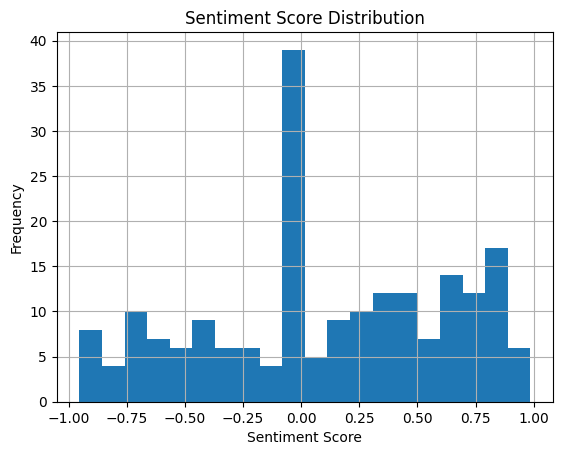

In [17]:
sia = SentimentIntensityAnalyzer()

dataset["sentiment"] = dataset["cleaned_post"].apply(lambda text: sia.polarity_scores(text)["compound"])

def lable(score):
    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    else:
        return "neutral"

dataset["sentiment_label"] = dataset["sentiment"].apply(lable)

dataset["sentiment"].hist(bins=20)
plt.title("Sentiment Score Distribution")
plt.xlabel("Sentiment Score")
plt.ylabel("Frequency")
plt.show()

From this histogram of result values from the Vadar model, we can see that there is quite a lot of "netural" values and there is more "positive" values than "negative" values.

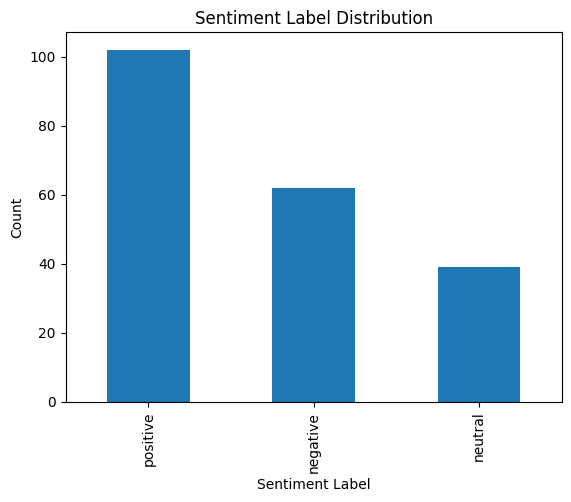

In [18]:
dataset["sentiment_label"].value_counts().plot(kind="bar")
plt.title("Sentiment Label Distribution")
plt.xlabel("Sentiment Label")
plt.ylabel("Count")
plt.show()

The created bar chart confirms our findings from the histogram. This directly contradicts our hypothesis so we will attempt to confirm or deny these results using two different bert models. These will be Distilbert Base and Twitter Roberta Base.

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 12307.65it/s]


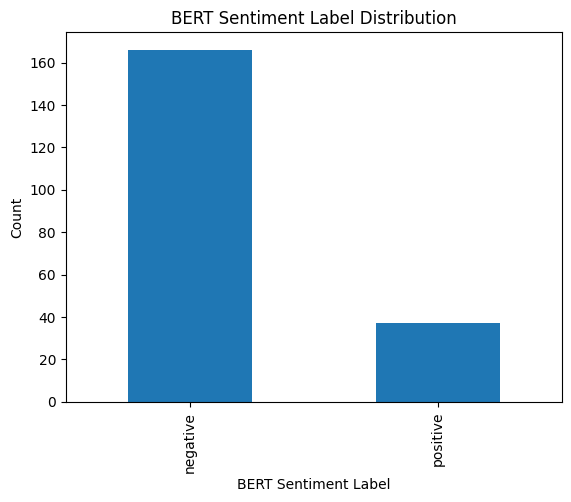

In [19]:
#bert_sentiment = pipeline("sentiment-analysis", model="nlptown/bert-base-multilingual-uncased-sentiment")
bert_sentiment = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")
def get_bert_sentiment(text):
    result = bert_sentiment(text[:512])[0]
    return result["label"], result["score"]

dataset[["bert_label", "bert_score"]] = dataset["cleaned_post"].apply(lambda x: pd.Series(get_bert_sentiment(x)))

dataset['bert_label'] = dataset['bert_label'].str.lower()

dataset["bert_label"].value_counts().plot(kind="bar")
plt.title("BERT Sentiment Label Distribution")
plt.xlabel("BERT Sentiment Label")
plt.ylabel("Count")
plt.show()

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 44948.56it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


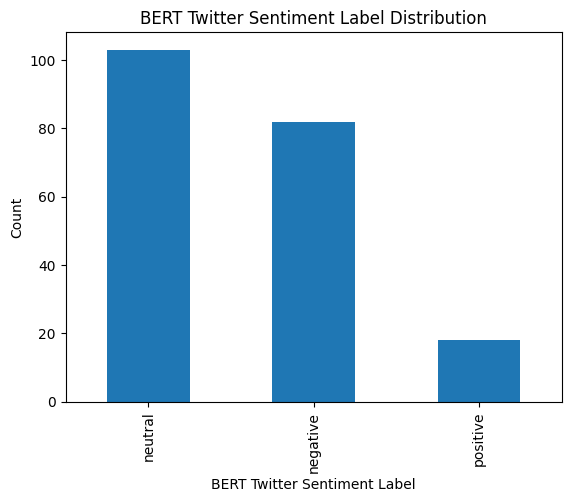

In [ ]:
bert_sentiment1 = pipeline("sentiment-analysis", model="cardiffnlp/twitter-roberta-base-sentiment-latest")
def get_bert_sentiment1(text):
    result = bert_sentiment1(text[:512])[0]
    return result["label"], result["score"]

dataset[["bert_label1", "bert_score1"]] = dataset["cleaned_post"].apply(lambda x: pd.Series(get_bert_sentiment1(x)))
dataset['bert_label1'] = dataset['bert_label1'].str.lower()

dataset["bert_label1"].value_counts().plot(kind="bar")
plt.title("BERT Twitter Sentiment Label Distribution")
plt.xlabel("BERT Twitter Sentiment Label")
plt.ylabel("Count")
plt.show()

The results from both the Distilbert Base and the Twitter Roberta Base models clearly show that our inital assumption is correct unlike the Vadar model. This could be because of a number of factors but it is most likly due to the major difference in the models. Due to the correlation of results between Distilbert Base and Twitter Roberta Base, they are more likly to be correct for our dataset rather than the Vadar results and thus will be used to determine our final thoughts.